# ORCA6 Figure 4: reconstructed versus true energy


In [21]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import uproot

DATA_DIR  = Path.cwd()  
ROOT_FILE = DATA_DIR / 'ORCA6_433kt-y_opendata_v0.5.root'
BIN_FILE  = DATA_DIR / 'bins_433kt-y_v0.5.json'


In [23]:
with BIN_FILE.open() as stream:
    binning = json.load(stream)

true_energy_edges = np.asarray(binning['E_true_bins'])

with uproot.open(ROOT_FILE) as root_file:
    response = root_file['binned_nu_response']
    values = response.arrays(
        ['AnaClass', 'E_true_bin_center', 'E_reco_bin_center', 'W'],
        library='np',
    )


In [49]:
def weighted_quantile(samples, weights, quantiles):
    order   = np.argsort(samples)
    samples = np.asarray(samples)[order]
    weights = np.asarray(weights)[order]
    cumulative_weight = np.cumsum(weights)
    return np.interp(np.asarray(quantiles) * cumulative_weight[-1], cumulative_weight, samples)

def energy_quantiles_for_class(ana_class):

    lower, median, upper = [], [], []
    class_rows = values['AnaClass'] == ana_class

    for left, right in zip(true_energy_edges[:-1], true_energy_edges[1:]):
        in_true_energy_bin = (left <= values['E_true_bin_center']) & (values['E_true_bin_center'] < right)
        rows = class_rows & in_true_energy_bin
        q16, q50, q84 = weighted_quantile(
            values['E_reco_bin_center'][rows], values['W'][rows], [0.16, 0.50, 0.84]
        )
        print(values['E_reco_bin_center'][rows])
        lower.append(q16)
        median.append(q50)
        upper.append(q84)

    return np.asarray(lower), np.asarray(median), np.asarray(upper)
    

[ 3.59646574  2.43208552  3.59646574  3.59646574  2.43208552  3.59646574
  2.43208552  2.43208552  2.43208552  2.43208552  3.59646574  2.43208552
  3.59646574  2.43208552  3.59646574  3.59646574  3.59646574  2.43208552
  2.43208552  2.43208552  2.43208552  2.43208552  3.59646574  2.43208552
  2.43208552  2.43208552  2.43208552  2.43208552  3.59646574  3.59646574
  2.43208552  3.59646574  2.43208552  7.13173548  3.59646574  3.59646574
  2.43208552  2.43208552  3.59646574  2.43208552  2.43208552  4.82279163
  2.43208552  3.59646574  2.43208552  2.43208552  2.43208552  3.59646574
  2.43208552  3.59646574  3.59646574  2.43208552  3.59646574  2.43208552
  2.43208552  2.43208552  2.43208552  3.59646574  2.43208552  2.43208552
  2.43208552  3.59646574  2.43208552  2.43208552  2.43208552  3.59646574
  3.59646574  2.43208552  7.13173548  2.43208552  3.59646574  3.59646574
  2.43208552  2.43208552  2.43208552  4.82279163  5.864715    2.43208552
  2.43208552  2.43208552  2.43208552  2.43208552  2

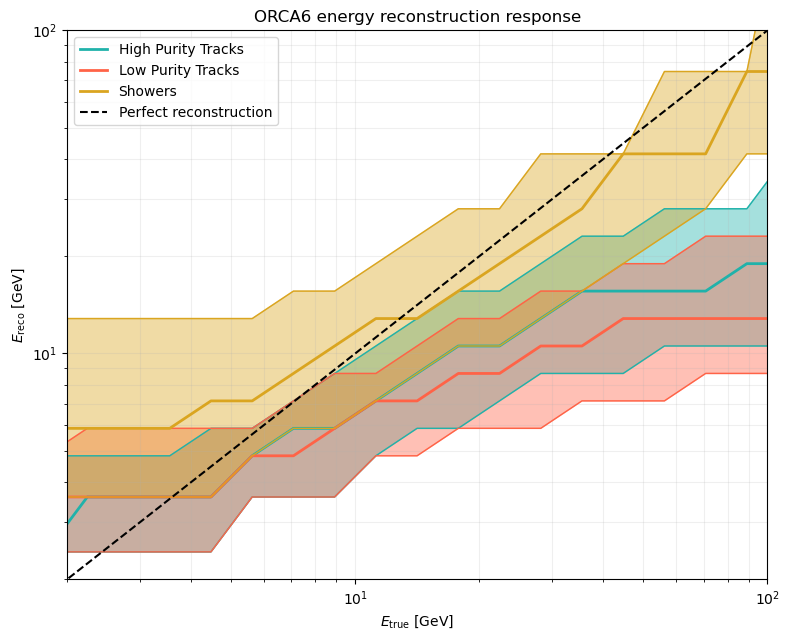

In [50]:
classes = {
    1: ('High Purity Tracks', 'lightseagreen'),
    3: ('Low Purity Tracks', 'tomato'),
    2: ('Showers', 'goldenrod'),
}
true_energy_centers = np.sqrt(true_energy_edges[:-1] * true_energy_edges[1:])

fig, ax = plt.subplots(figsize=(8, 6.5))
for ana_class, (label, color) in classes.items():
    q16, q50, q84 = energy_quantiles_for_class(ana_class)
    ax.fill_between(true_energy_centers, q16, q84, color=color, alpha=0.40)
    ax.plot(true_energy_centers, q16, color=color, lw=1)
    ax.plot(true_energy_centers, q50, color=color, lw=2, label=label)
    ax.plot(true_energy_centers, q84, color=color, lw=1)

diagonal = np.array([1.0, 1.0e4])
ax.plot(diagonal, diagonal, 'k--', lw=1.5, label='Perfect reconstruction')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2, 1.0e2)
ax.set_ylim(2, 1.0e2)
ax.set_xlabel(r'$E_{\mathrm{true}}$ [GeV]')
ax.set_ylabel(r'$E_{\mathrm{reco}}$ [GeV]')
ax.set_title('ORCA6 energy reconstruction response')
ax.grid(which='both', alpha=0.2)
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()
